# Print-head Durability: 99% Confidence Intervals
The assignment asks for the population mean durability of print-heads, measured in **millions of characters before failure**. Fifteen randomly selected print-heads were tested destructively. Two cases are evaluated: unknown population standard deviation and a known population standard deviation of 0.2 million characters.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

BASE = Path.cwd()
if BASE.name in ('notebooks', 'src'):
    BASE = BASE.parent
for folder in ('results', 'figures'):
    (BASE / folder).mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

from scipy import stats

## 1. Data and assumptions
The observations are copied from the supplied assignment. The sample is assumed random, independent, and representative. With only 15 observations, the t interval requires an approximately normal population for reliable exact coverage. The known-sigma z interval is exact under normality; knowing sigma alone does not eliminate that assumption for a small sample. The observed sample cannot prove normality.

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
durability_million_characters,1.13,1.55,1.43,0.92,1.25,1.36,1.32,0.85,1.07,1.48,1.2,1.33,1.18,1.22,1.29


n = 15, mean = 1.238666667, sample SD = 0.193164130


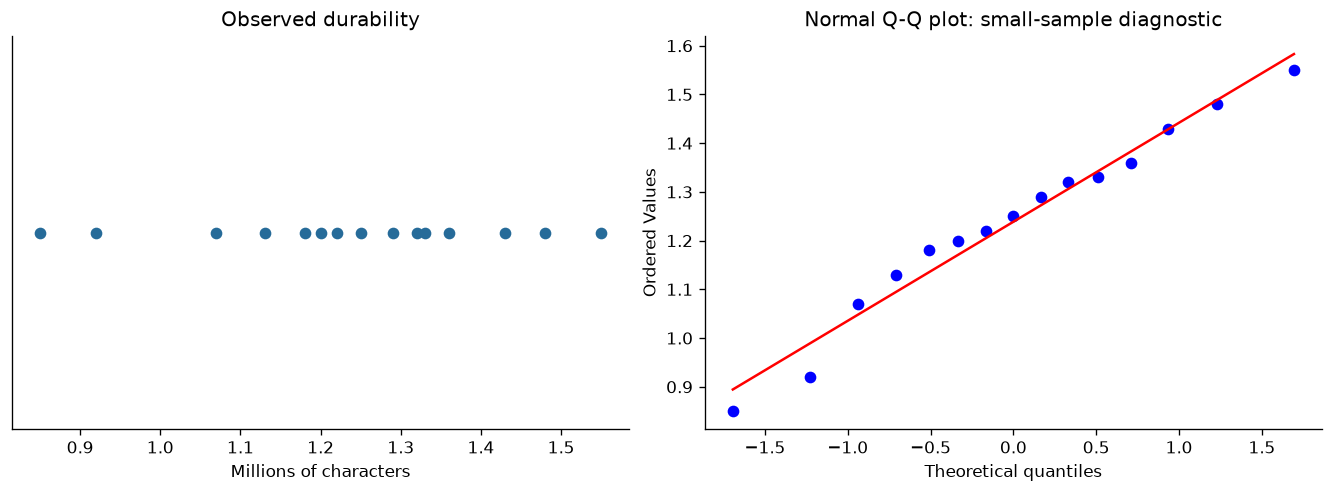

In [2]:
data = pd.read_csv(BASE/'data/print_head_durability.csv')
x = data['durability_million_characters'].to_numpy()
n = x.size
mean = x.mean()
s = x.std(ddof=1)
confidence = 0.99
alpha = 1 - confidence
display(data.T)
print(f'n = {n}, mean = {mean:.9f}, sample SD = {s:.9f}')
assert n == 15 and np.isfinite(x).all()
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].scatter(x, np.zeros(n), color='#266b99')
axes[0].set(title='Observed durability', xlabel='Millions of characters', yticks=[])
stats.probplot(x, dist='norm', plot=axes[1])
axes[1].set_title('Normal Q-Q plot: small-sample diagnostic')
fig.savefig(BASE/'figures/sample_diagnostics.png'); plt.show()

## 2. Part (a): unknown population standard deviation
Estimate sigma with the sample SD, calculated with n − 1 in the variance denominator. The standardized mean then follows a Student t distribution with **14 degrees of freedom** under the normal-population assumption. This accounts for uncertainty in estimating sigma.

For a two-sided 99% interval, each tail has probability 0.005:

**SE = s / √n; margin = t(0.995, 14) × SE; CI = sample mean ± margin.**

In [3]:
dfree = n - 1
t_critical = stats.t.ppf(1-alpha/2, dfree)
se_t = s / np.sqrt(n)
margin_t = t_critical * se_t
ci_t = (mean-margin_t, mean+margin_t)
print(f't critical = {t_critical:.9f}; SE = {se_t:.9f}; margin = {margin_t:.9f}')
print(f'99% t interval: ({ci_t[0]:.6f}, {ci_t[1]:.6f}) million characters')
assert np.allclose(ci_t, stats.t.interval(confidence, dfree, loc=mean, scale=stats.sem(x)))

t critical = 2.976842734; SE = 0.049874764; margin = 0.148469328
99% t interval: (1.090197, 1.387136) million characters


## 3. Part (b): known population standard deviation
The assignment now specifies **sigma = 0.2 million characters**. Use the standard normal critical value because sigma is known, rather than replacing it with the sample SD.

**SE = 0.2 / √15; margin = z(0.995) × SE; CI = sample mean ± margin.**

In [4]:
sigma = 0.2
z_critical = stats.norm.ppf(1-alpha/2)
se_z = sigma / np.sqrt(n)
margin_z = z_critical * se_z
ci_z = (mean-margin_z, mean+margin_z)
print(f'z critical = {z_critical:.9f}; SE = {se_z:.9f}; margin = {margin_z:.9f}')
print(f'99% z interval: ({ci_z[0]:.6f}, {ci_z[1]:.6f}) million characters')
assert np.allclose(ci_z, stats.norm.interval(confidence, loc=mean, scale=se_z))
# Independent standard-library check for the z critical value.
from statistics import NormalDist, mean as arithmetic_mean, stdev
assert np.isclose(z_critical, NormalDist().inv_cdf(.995))
assert np.isclose(mean, arithmetic_mean(x)) and np.isclose(s, stdev(x))

z critical = 2.575829304; SE = 0.051639778; margin = 0.133015253
99% z interval: (1.105651, 1.371682) million characters


## 4. Compare results and interpret

,method,n,confidence,sample_mean,SD_used,df,critical_value,standard_error,margin,lower,upper,width
0,Unknown sigma (t),15,0.99,1.238667,0.193164,14.0,2.976843,0.049875,0.148469,1.090197,1.387136,0.296939
1,Known sigma (z),15,0.99,1.238667,0.200000,NaN,2.575829,0.051640,0.133015,1.105651,1.371682,0.266031


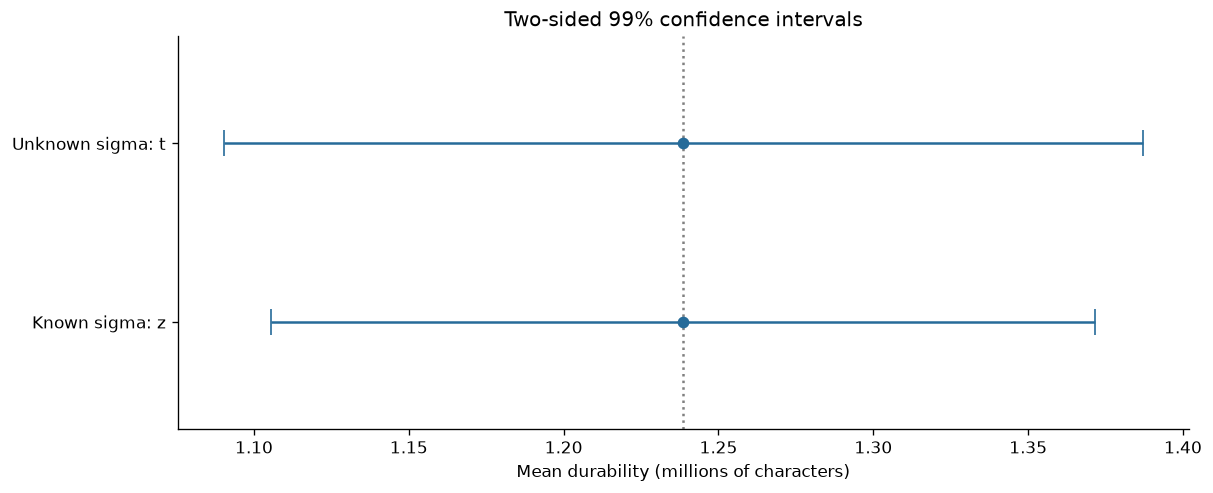

t width = 0.296939; z width = 0.266031


In [5]:
results = pd.DataFrame([
    ['Unknown sigma (t)', n, confidence, mean, s, dfree, t_critical, se_t, margin_t, *ci_t, 2*margin_t],
    ['Known sigma (z)', n, confidence, mean, sigma, np.nan, z_critical, se_z, margin_z, *ci_z, 2*margin_z]],
    columns=['method','n','confidence','sample_mean','SD_used','df','critical_value','standard_error',
             'margin','lower','upper','width'])
display(results)
results.to_csv(BASE/'results/confidence_intervals.csv', index=False)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.errorbar([mean, mean], [1, 0], xerr=[margin_t, margin_z], fmt='o', capsize=8, color='#266b99')
ax.set(yticks=[0,1], yticklabels=['Known sigma: z', 'Unknown sigma: t'],
       xlabel='Mean durability (millions of characters)', title='Two-sided 99% confidence intervals', ylim=(-.6,1.6))
ax.axvline(mean, linestyle=':', color='gray')
fig.savefig(BASE/'figures/confidence_intervals.png'); plt.show()
print(f't width = {2*margin_t:.6f}; z width = {2*margin_z:.6f}')

## 5. Answers and conclusion
The sample mean is **1.238667 million characters** and the sample SD is **0.193164 million**.

- **(a) Unknown sigma:** the 99% t interval is approximately **(1.0902, 1.3871) million characters**.
- **(b) Known sigma = 0.2:** the 99% z interval is approximately **(1.1057, 1.3717) million characters**.

The t interval is wider in this dataset because its larger critical value more than offsets the slightly smaller estimated SD. This comparison is specific to these inputs; a t interval is not necessarily wider if the supplied known sigma is much larger.

Under repeated random sampling with the stated assumptions, 99% of intervals constructed by each procedure would contain the fixed population mean. This does **not** mean 99% of individual print-head lifetimes fall in the interval, nor that there is a 99% frequentist probability that this already computed interval contains the mean. These are intervals for the mean, not prediction or tolerance intervals.

The sample is small and no minimum quality specification is given, so this analysis cannot establish whether the product meets a required standard.

**Source:** supplied `Basic stats - 2.zip`, `Confidence Interval.docx`. All 15 observations and the known sigma are transcribed into the accompanying data file and code.